# **Module End  Assignment: Python For Data Analysis**


## **Social Media Engagement Analytics**



## **Task 1 — Data Import & Setup**

In [ ]:
# Import CSV using Pandas

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
social_df=pd.read_csv("https://github.com/GeethaGunasekaran1/Dataset_rep/raw/refs/heads/main/social_media_engagement_5000.csv")
social_df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
social_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
# Check/convert data types
# Convert date columns to datetime

social_df['posted_at'].dtype

dtype('O')

In [ ]:
social_df['posted_at'] = pd.to_datetime(social_df['posted_at'], errors='coerce')

/tmp/ipykernel_12743/1071989534.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  social_df['posted_at'] = pd.to_datetime(social_df['posted_at'], errors='coerce')


In [ ]:
social_df['posted_at'].dtype

dtype('<M8[ns]')

In [ ]:
social_df['year'] = social_df['posted_at'].dt.year
social_df['month'] = social_df['posted_at'].dt.month
social_df['day'] = social_df['posted_at'].dt.day

## **Task 2 — Data Cleaning**

In [ ]:
# Handling missing value

social_df.isna().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
social_df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,year,month,day
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,2022.493800,6.499200,15.838600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,2022.000000,1.000000,1.000000
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,2022.000000,4.000000,8.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2022.000000,7.000000,16.000000
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,2023.000000,9.000000,23.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,2023.000000,12.000000,31.000000
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.500012,3.443599,8.750695


In [ ]:
social_df.describe(include="all")

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,year,month,day
count,5000.000000,4850.000000,4850,5000,5000.000000,5000,5000,4850.000000,4850.000000,4850.000000,...,5000,5000.000000,5000,5000,4850,5000,5000.000000,5000.000000,5000.000000,5000.000000
unique,NaN,NaN,3,10,NaN,4,8,NaN,NaN,NaN,...,NaN,NaN,2,3,3,761,NaN,NaN,NaN,NaN
top,NaN,NaN,Male,India,NaN,reel,fitness,NaN,NaN,NaN,...,NaN,NaN,False,mobile,positive,#tech,NaN,NaN,NaN,NaN
freq,NaN,NaN,1699,535,NaN,1283,675,NaN,NaN,NaN,...,NaN,NaN,4517,1684,2363,201,NaN,NaN,NaN,NaN
mean,54561.890800,38.454021,NaN,NaN,548042.909000,NaN,NaN,10107.043711,1502.195670,1002.629485,...,2022-12-28 13:21:30.240000,393698.224800,NaN,NaN,NaN,NaN,0.964356,2022.493800,6.499200,15.838600
min,10055.000000,13.000000,NaN,NaN,100068.000000,NaN,NaN,10.000000,0.000000,0.000000,...,2022-01-01 00:00:00,87.000000,NaN,NaN,NaN,NaN,0.006363,2022.000000,1.000000,1.000000
25%,32309.500000,26.000000,NaN,NaN,322543.500000,NaN,NaN,5068.500000,760.000000,498.000000,...,2022-07-03 18:00:00,194480.000000,NaN,NaN,NaN,NaN,0.145781,2022.000000,4.000000,8.000000
50%,54374.500000,38.000000,NaN,NaN,548077.500000,NaN,NaN,10105.500000,1497.000000,1012.000000,...,2022-12-27 00:00:00,388982.000000,NaN,NaN,NaN,NaN,0.253896,2022.000000,7.000000,16.000000
75%,77180.500000,51.000000,NaN,NaN,771574.500000,NaN,NaN,15115.000000,2256.000000,1501.000000,...,2023-06-28 00:00:00,589744.250000,NaN,NaN,NaN,NaN,0.504794,2023.000000,9.000000,23.000000
max,99963.000000,64.000000,NaN,NaN,999455.000000,NaN,NaN,19998.000000,2999.000000,1999.000000,...,2023-12-31 00:00:00,799533.000000,NaN,NaN,NaN,NaN,191.504348,2023.000000,12.000000,31.000000


In [ ]:
# Numerical Columns → Median
numeric_cols = ['age', 'likes', 'comments', 'shares']

In [ ]:
for col in numeric_cols:
    social_df[col].fillna(social_df[col].median(), inplace=True)

In [ ]:
# Categorical Columns → Mode
categorical_cols = ['gender', 'sentiment']

for col in categorical_cols:
    social_df[col].fillna(social_df[col].mode()[0], inplace=True)

Missing values in numerical columns such as age, likes, comments, and shares were treated using median imputation due to the presence of outliers. Categorical columns such as gender and sentiment were handled using mode imputation to preserve the most frequently occurring category.

In [ ]:
# Duplicate Handling- Identify & remove duplicates
social_df.duplicated().sum()

np.int64(0)

In [ ]:
social_df.drop_duplicates(inplace=True)

Duplicate records were identified using duplicated() and removed using drop_duplicates() to improve data quality and avoid repeated observations.

**Data Formatting**

In [ ]:
social_df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [ ]:
social_df['gender'] = social_df['gender'].str.lower().str.strip()

In [ ]:
social_df['sentiment'] = social_df['sentiment'].str.capitalize().str.strip()

In [ ]:
social_df['gender'].unique()

array(['female', 'male', 'other'], dtype=object)

In [ ]:
social_df['sentiment'].unique()

array(['Negative', 'Positive', 'Neutral'], dtype=object)

In [ ]:
social_df[social_df['likes'] < 0]

social_df[social_df['comments'] < 0]

social_df[social_df['shares'] < 0]

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,year,month,day


No unrealistic negative values found

In [ ]:
#  Feature Cleaning
# Extract hashtag count

social_df['hashtags'].head()

,hashtags
0,#foodie #travel #love
1,#fitness
2,#foodie
3,#music #foodie #fun
4,#travel


In [ ]:
social_df['hashtag_count'] = social_df['hashtags'].fillna('').apply(lambda x: len(str(x).split()))

In [ ]:
social_df[['hashtags', 'hashtag_count']].head()

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


A new feature called hashtag_count was created by counting the number of hashtags used in each post. This helps analyze whether hashtag usage impacts engagement levels.

In [ ]:
# Clean Sentiment Labels
social_df['sentiment'].unique()

array(['Negative', 'Positive', 'Neutral'], dtype=object)

In [ ]:
social_df['sentiment'].unique()

array(['Negative', 'Positive', 'Neutral'], dtype=object)

## ***Task 3 — Data Exploration using Pandas***

In [ ]:
social_df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,year,month,day,hashtag_count
0,25795,43.0,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,81734,False,mobile,Negative,#foodie #travel #love,0.190862,2022,12,17,3
1,10860,33.0,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,5963,False,mobile,Negative,#fitness,0.201493,2023,6,2,1
2,86820,32.0,female,UK,109864,text,food,4862.0,344.0,955.0,...,501783,False,tablet,Positive,#foodie,0.137345,2023,5,7,1
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,480212,False,mobile,Negative,#music #foodie #fun,0.106195,2023,2,12,3
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,383936,False,mobile,Negative,#travel,2.777372,2023,5,23,1


In [ ]:
social_df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,year,month,day,hashtag_count
4995,59500,44.0,male,Australia,441541,video,education,16210.0,2013.0,1837.0,...,646147,False,mobile,Positive,#travel #fun,0.466761,2022,6,25,2
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,...,584603,False,desktop,Negative,#foodie #reels,0.621155,2022,11,18,2
4997,67021,63.0,female,USA,273595,text,travel,13487.0,1497.0,167.0,...,483550,False,desktop,Positive,#lifestyle #tech,0.679688,2023,4,6,2
4998,29800,13.0,female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,...,183295,False,tablet,Positive,#reels #love #fitness,0.223518,2022,5,16,3
4999,73400,54.0,other,Japan,712252,text,travel,14830.0,503.0,1798.0,...,585760,False,desktop,Neutral,#foodie #lifestyle #fashion,1.203527,2023,3,4,3


In [ ]:
social_df.shape


(5000, 23)

In [ ]:
social_df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'year',
       'month', 'day', 'hashtag_count'],
      dtype='object')

In [ ]:
social_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
social_df.dtypes


,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
social_df.describe(include="all")

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,year,month,day,hashtag_count
count,5000.000000,5000.000000,5000,5000,5000.000000,5000,5000,5000.000000,5000.000000,5000.0000,...,5000.000000,5000,5000,5000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
unique,NaN,NaN,3,10,NaN,4,8,NaN,NaN,NaN,...,NaN,2,3,3,761,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,male,India,NaN,reel,fitness,NaN,NaN,NaN,...,NaN,False,mobile,Positive,#tech,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1849,535,NaN,1283,675,NaN,NaN,NaN,...,NaN,4517,1684,2513,201,NaN,NaN,NaN,NaN,NaN
mean,54561.890800,38.440400,NaN,NaN,548042.909000,NaN,NaN,10106.997400,1502.039800,1002.9106,...,393698.224800,NaN,NaN,NaN,NaN,0.964356,2022.493800,6.499200,15.838600,1.998600
min,10055.000000,13.000000,NaN,NaN,100068.000000,NaN,NaN,10.000000,0.000000,0.0000,...,87.000000,NaN,NaN,NaN,NaN,0.006363,2022.000000,1.000000,1.000000,1.000000
25%,32309.500000,26.000000,NaN,NaN,322543.500000,NaN,NaN,5235.000000,792.000000,511.0000,...,194480.000000,NaN,NaN,NaN,NaN,0.145781,2022.000000,4.000000,8.000000,1.000000
50%,54374.500000,38.000000,NaN,NaN,548077.500000,NaN,NaN,10105.500000,1497.000000,1012.0000,...,388982.000000,NaN,NaN,NaN,NaN,0.253896,2022.000000,7.000000,16.000000,2.000000
75%,77180.500000,51.000000,NaN,NaN,771574.500000,NaN,NaN,14959.000000,2235.250000,1483.0000,...,589744.250000,NaN,NaN,NaN,NaN,0.504794,2023.000000,9.000000,23.000000,3.000000
max,99963.000000,64.000000,NaN,NaN,999455.000000,NaN,NaN,19998.000000,2999.000000,1999.0000,...,799533.000000,NaN,NaN,NaN,NaN,191.504348,2023.000000,12.000000,31.000000,3.000000


In [ ]:
# Analyze categorical distributions using value_counts(), unique(), and nunique().
social_df['gender'].value_counts()

,count
gender,
male,1849
other,1581
female,1570


In [ ]:
social_df['gender'].value_counts()

,count
gender,
male,1849
other,1581
female,1570


In [ ]:
social_df['post_type'].value_counts()

,count
post_type,
reel,1283
image,1247
text,1245
video,1225


In [ ]:
social_df['country'].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [ ]:
social_df['country'].nunique()

10

In [ ]:
social_df.groupby('post_type')['likes'].mean().sort_values(ascending=False)

,likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


In [ ]:
social_df.groupby('sentiment')['comments'].mean()

,comments
sentiment,
Negative,1516.094792
Neutral,1528.404060
Positive,1480.650617


In [ ]:
social_df.groupby('country')['shares'].mean().sort_values(ascending=False)

,shares
country,
France,1051.812500
India,1035.315888
Australia,1029.693712
Brazil,1008.859127
Canada,996.245614
USA,995.141717
UAE,989.075547
UK,985.681542
Germany,973.379592


In [ ]:
social_df.groupby('post_category')['engagement_rate'].mean()

,engagement_rate
post_category,
education,0.844222
fashion,0.807109
fitness,0.865628
food,1.358628
lifestyle,1.091019
music,0.888803
tech,1.160475
travel,0.702223


In [ ]:
social_df.groupby('is_verified')['follower_count'].mean()

,follower_count
is_verified,
False,395042.837503
True,381123.451346


In [ ]:
social_df.groupby('post_type')[['likes', 'comments', 'shares']].mean()


,likes,comments,shares
post_type,,,
image,10104.865277,1525.235766,1019.289495
reel,10037.802416,1504.187062,982.042089
text,10100.148193,1499.106024,1013.989558
video,10188.600000,1479.160000,996.834286


In [ ]:
social_df.groupby('country')[['likes', 'comments', 'shares']].mean()

,likes,comments,shares
country,,,
Australia,10294.124746,1485.803245,1029.693712
Brazil,9886.689484,1490.434524,1008.859127
Canada,10063.066277,1546.582846,996.245614
France,10372.876008,1478.695565,1051.812500
Germany,10130.458163,1531.826531,973.379592
India,9962.468224,1494.917757,1035.315888
Japan,10088.862288,1530.434322,959.351695
UAE,10227.487078,1541.214712,989.075547
UK,9935.650101,1463.042596,985.681542


In [ ]:
social_df.groupby('sentiment')[['likes', 'comments', 'shares']].mean()

,likes,comments,shares
sentiment,,,
Negative,10208.096875,1516.094792,1007.307292
Neutral,9923.194499,1528.404060,996.565160
Positive,10180.062077,1480.650617,1005.086749


In [ ]:
summary = social_df.groupby('post_type').agg({
    'likes': ['mean', 'max', 'count'],
    'comments': ['mean', 'max', 'count'],
    'shares': ['mean', 'max', 'count']
})

summary

likes                    comments                \
                   mean      max count         mean     max count   
post_type                                                           
image      10104.865277  19996.0  1247  1525.235766  2997.0  1247   
reel       10037.802416  19994.0  1283  1504.187062  2999.0  1283   
text       10100.148193  19998.0  1245  1499.106024  2999.0  1245   
video      10188.600000  19995.0  1225  1479.160000  2999.0  1225   

                shares                
                  mean     max count  
post_type                             
image      1019.289495  1998.0  1247  
reel        982.042089  1999.0  1283  
text       1013.989558  1999.0  1245  
video       996.834286  1999.0  1225

In [ ]:
social_df.isna().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


## **Task 5 — Statistical Analysis **

In [ ]:
stats_cols = ['likes',
              'comments',
              'shares',
              'watch_time_sec',
              'engagement_rate',
              'follower_count']

In [ ]:
summary_stats = pd.DataFrame({
    'Mean': social_df[stats_cols].mean(),
    'Median': social_df[stats_cols].median(),
    'Mode': social_df[stats_cols].mode().iloc[0],
    'Std Dev': social_df[stats_cols].std(),
    'Variance': social_df[stats_cols].var(),
    '25%': social_df[stats_cols].quantile(0.25),
    '50%': social_df[stats_cols].quantile(0.50),
    '75%': social_df[stats_cols].quantile(0.75)
})

summary_stats

,Mean,Median,Mode,Std Dev,Variance,25%,50%,75%
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000


Descriptive statistical analysis was performed on engagement-related numerical variables including likes, comments, shares, watch time, engagement rate, and follower count. Measures such as mean, median, mode, standard deviation, variance, and percentiles were calculated to understand data distribution, variability, and central tendency.

In [ ]:
# Box plot outliers

num_cols = [
    'age',
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'impression_count',
    'engagement_rate',
    'follower_count'
]

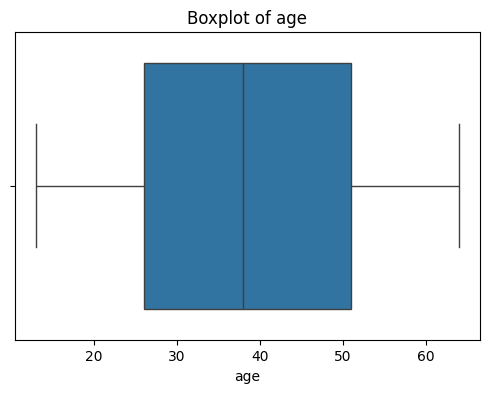

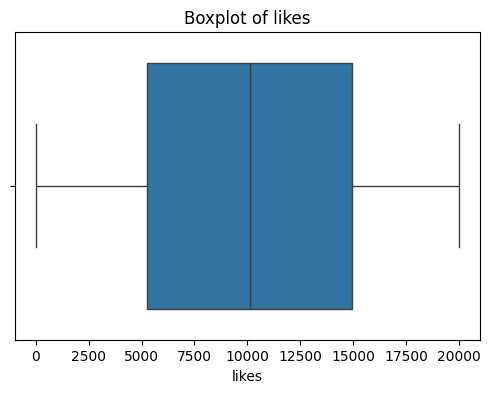

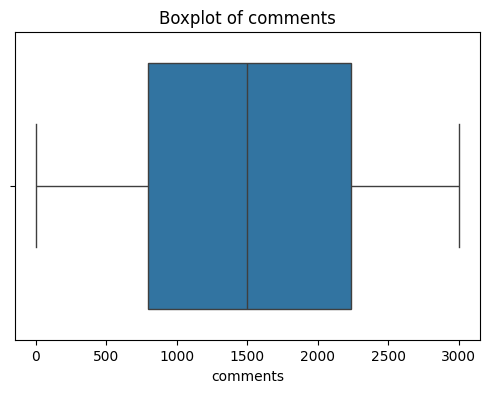

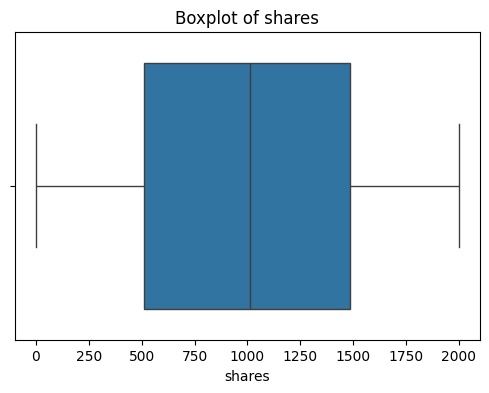

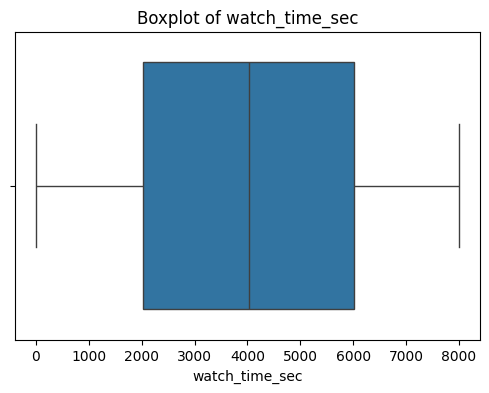

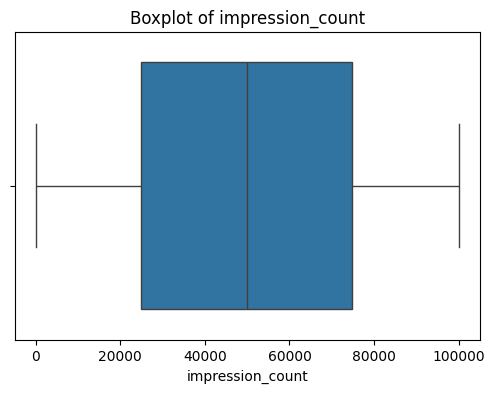

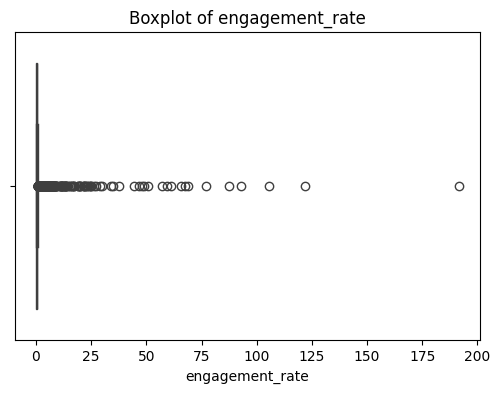

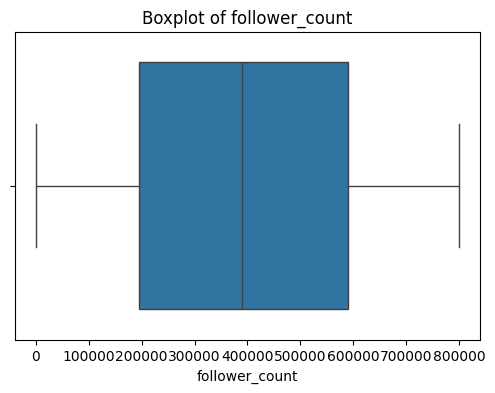

In [ ]:
for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=social_df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

Outliers were mainly found in engagement_rate, why it has outlier

* some social media posts become viral
* viral posts receive extremely high engagement

In [ ]:
social_df[num_cols].skew()

,0
age,0.023713
likes,-0.006894
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
impression_count,0.015232
engagement_rate,18.781271
follower_count,0.041118


In [ ]:
social_df[num_cols].kurtosis()

,0
age,-1.133449
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
impression_count,-1.198398
engagement_rate,482.991739
follower_count,-1.189474


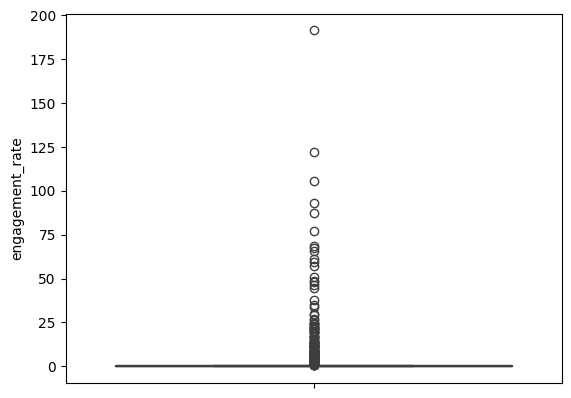

In [ ]:
# log transformation

# Box plot for engagement_rate



sns.boxplot(social_df['engagement_rate'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

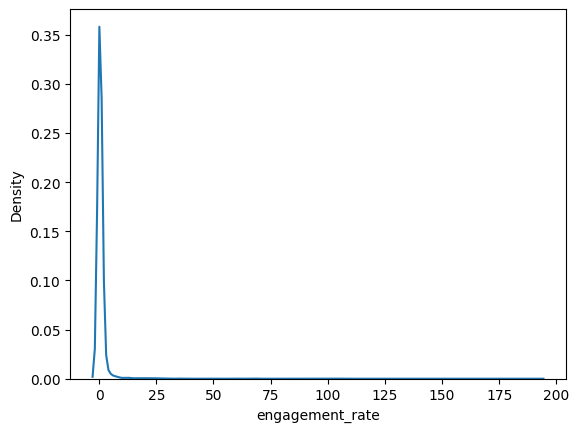

In [ ]:
sns.kdeplot(social_df["engagement_rate"])
plt.show

In [ ]:
import numpy as np
social_df['engagement_rate_log'] = np.log1p(social_df['engagement_rate'])

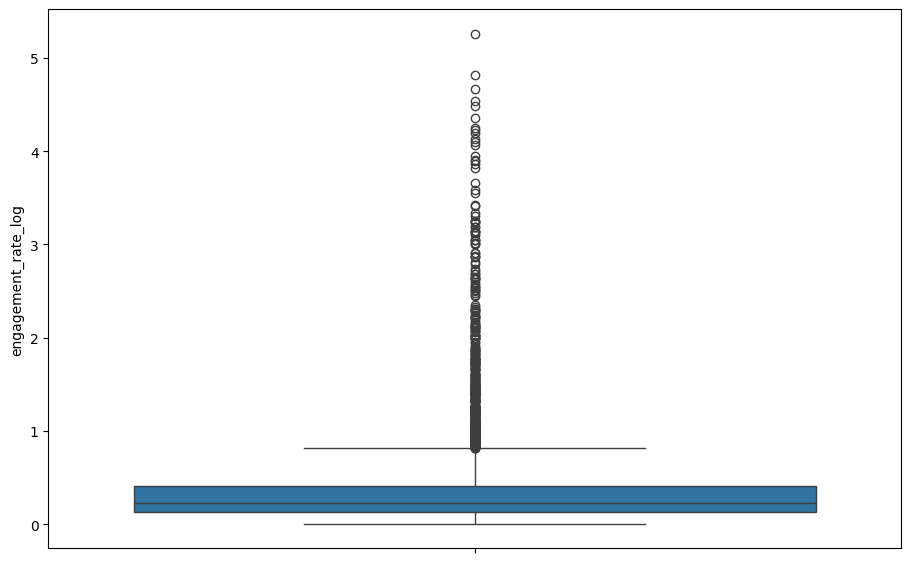

In [ ]:

plt.figure(figsize=(11,7))
sns.boxplot(data=social_df['engagement_rate_log'])
plt.show()

In [ ]:
print("Original Skewness :", social_df['engagement_rate'].skew())

Original Skewness : 18.781270878869154


In [ ]:
social_df['engagement_rate_log'].skew()

np.float64(4.091481846802278)

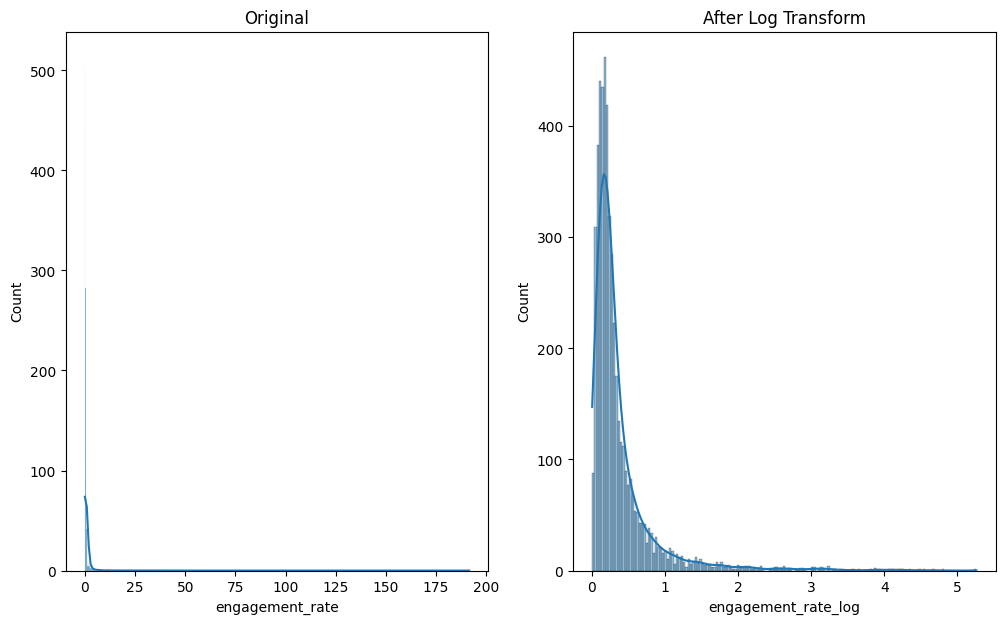

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,7))

sns.histplot(social_df['engagement_rate'], kde=True, ax=ax[0])
ax[0].set_title("Original")

sns.histplot(social_df['engagement_rate_log'], kde=True, ax=ax[1])
ax[1].set_title("After Log Transform")

plt.show()

 * The engagement_rate column showed extremely high skewness (18.78)and kurtosi,  the distribution was heavily right-skewed.
 * Log transformation reduced this imbalance and made the distribution more stable.
* Since these values may represent genuine viral social media interactions rather than invalid records, log transformation was applied instead of capping

# **Task 6 — Data Visualization**

# **Scatter: likes vs impressions**

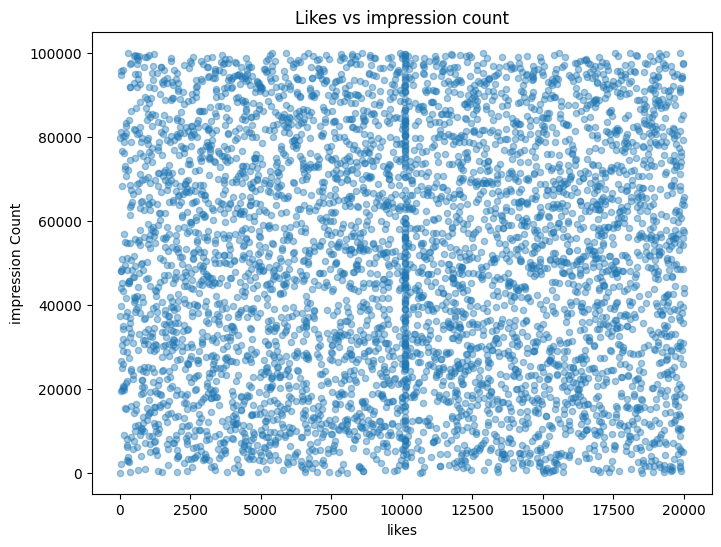

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(social_df['likes'],social_df['impression_count'], alpha=0.4,s=20)
plt.xlabel('likes')
plt.ylabel('impression Count')
plt.title('Likes vs impression count')

plt.show()

**Insight**

* The scatter plot showed a highly dispersed relationship between likes and impression count, indicating that higher impressions did not always result in proportionally higher likes.
* Audience interaction patterns varied significantly across posts.

## **Line: daily engagement trend**

In [ ]:
daily_engagement = social_df.groupby('posted_at')['engagement_rate'].mean()

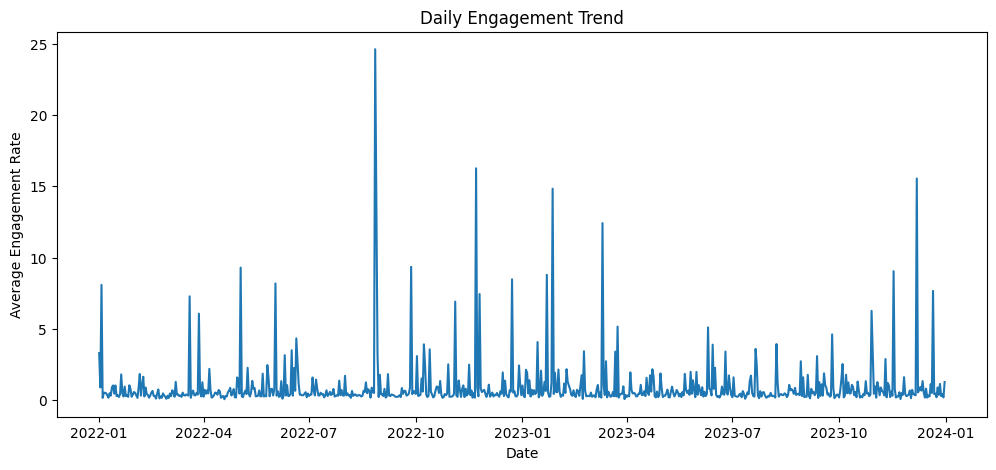

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(daily_engagement)
plt.title('Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Average Engagement Rate')

plt.show()

**Insight**

Daily engagement levels fluctuated over time, showing inconsistent audience interaction patterns with 2022 periods experiencing noticeably higher engagement activity.

# **Bar: posts by category**

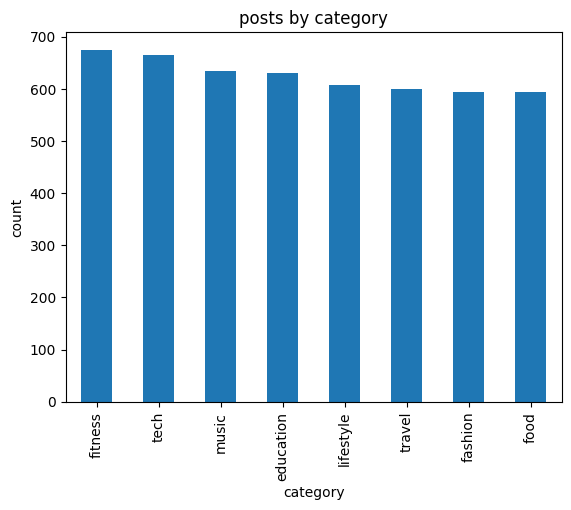

In [ ]:
social_df['post_category'].value_counts().plot(kind='bar')

plt.title('posts by category')
plt.xlabel('category')
plt.ylabel('count')

plt.show()

**Insight**

 Fitness categories were posted more frequently than others,the comes tech indicating stronger creator focus and audience demand for specific content themes.

## **Pie: gender distribution**

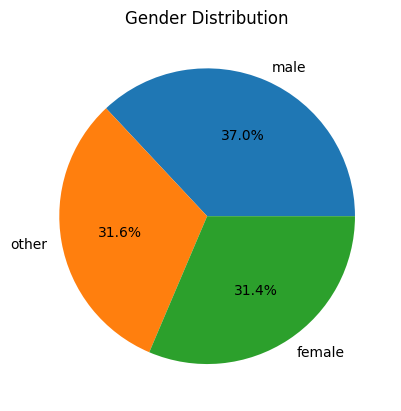

In [ ]:
social_df['gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

**Insight**

The dataset showed participation from multiple gender groups, with Male category contributing a larger share of overall platform activity and engagement.

## **Histogram: age**

In [ ]:
social_df['age'].describe()

,age
count,5000.000000
mean,38.440400
std,14.687151
min,13.000000
25%,26.000000
50%,38.000000
75%,51.000000
max,64.000000


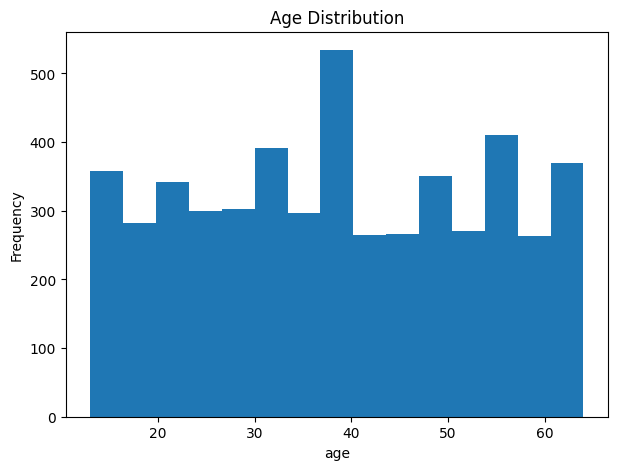

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(social_df["age"],bins=15)
plt.title("Age Distribution")
plt.xlabel('age')
plt.ylabel('Frequency')
plt.show()

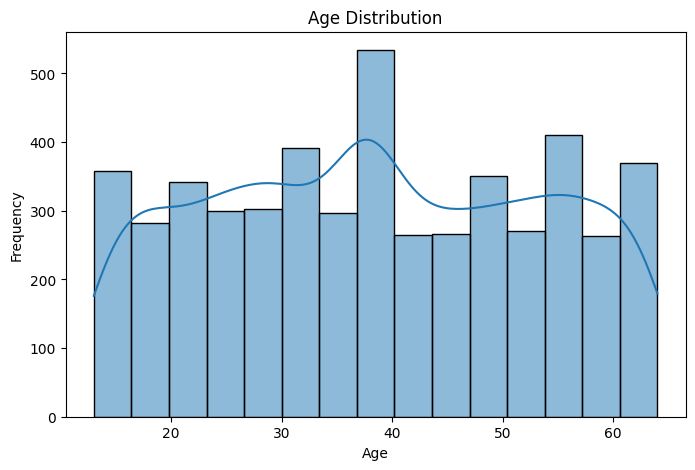

In [122]:
plt.figure(figsize=(8,5))

sns.histplot(
    social_df['age'],
    bins=15,
    kde=True
)

plt.title('Age Distribution')

plt.xlabel('Age')

plt.ylabel('Frequency')

plt.show()

**Insight**

Users aged between 31–40 formed the largest audience group in the dataset, indicating stronger engagement participation among middle-aged users.

## **Highest Engagement Hashtags**

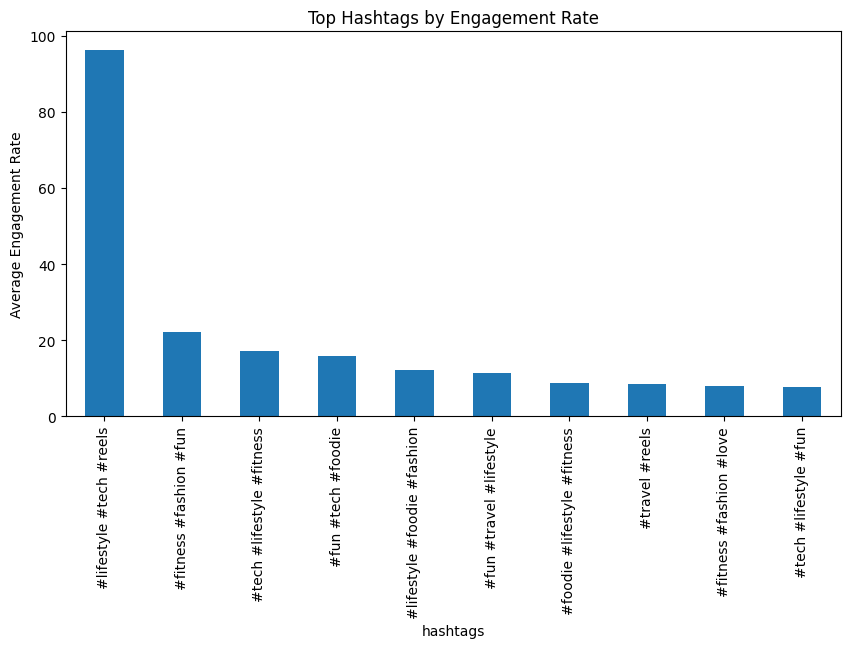

In [121]:
top_hash_eng = social_df.groupby('hashtags')['engagement_rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_hash_eng.plot(kind='bar')

plt.title('Top Hashtags by Engagement Rate')

plt.ylabel('Average Engagement Rate')

plt.show()

**Insights**

Hashtags such as #lifestyle,#tech and #travel generated the highest average engagement rates, indicating stronger audience interest in these topics.

## **SEABORN VISUALIZATIONS**

## **Count plot: post type**

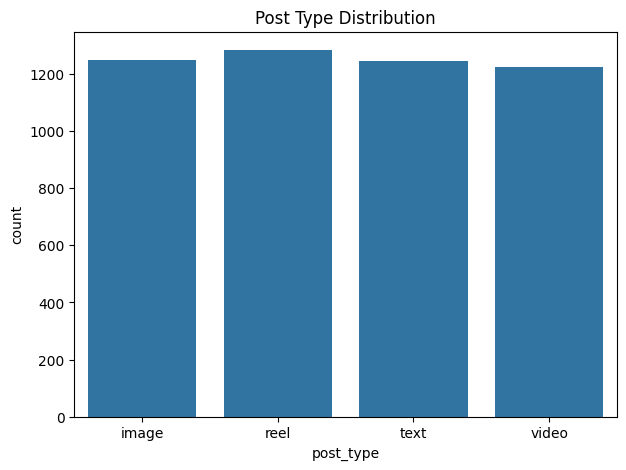

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x='post_type',
              data=social_df)

plt.title('Post Type Distribution')

plt.show()

**Insight**

reel post types were published more frequently, showing content preference trends among creators.

## **Bar plot: avg likes by category**

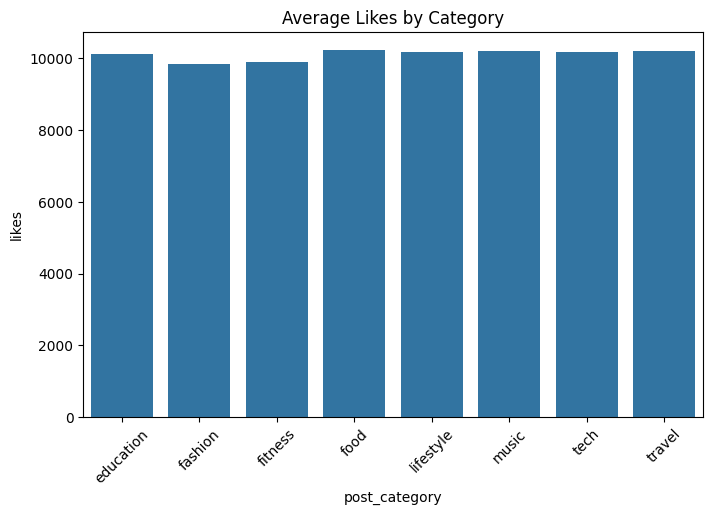

In [ ]:
avg_likes = social_df.groupby('post_category')['likes'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='post_category',y='likes',data=avg_likes)
plt.xticks(rotation=45)
plt.title('Average Likes by Category')

plt.show()

**Insight**

Certain categories received significantly higher average likes, most are equal indicating stronger audience interest and interaction.

## **Violin: followers vs sentiment**

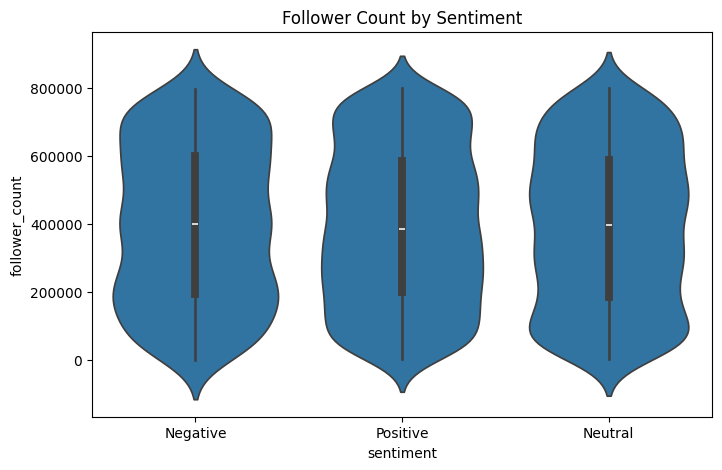

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(x='sentiment',y='follower_count',data=social_df)
plt.title('Follower Count by Sentiment')
plt.show()

**Insight**

* Follower distribution varied across sentiment categories, suggesting that audience interaction may differ based on post sentiment.
* Here Negative sentiment posts generated the highest engagement rates.

## **Pair plot: numeric features**

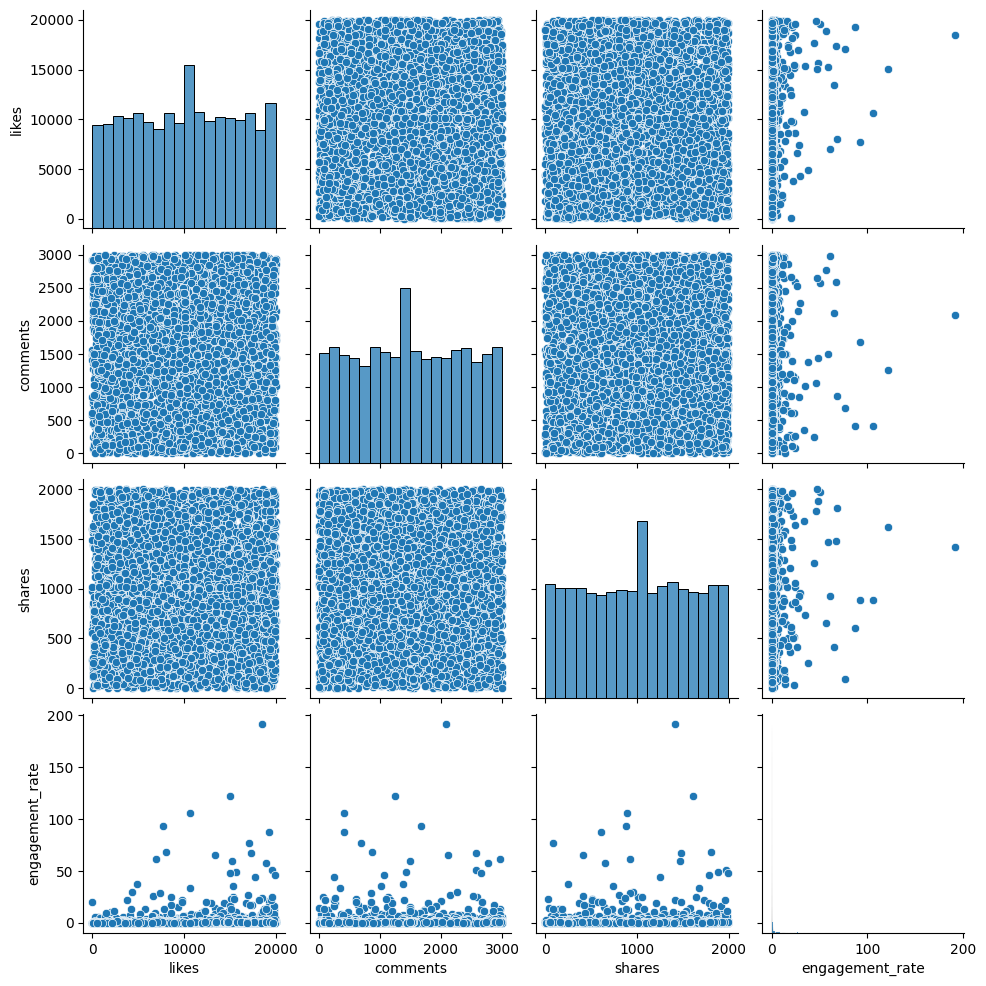

In [ ]:
sns.pairplot(
    social_df[['likes','comments','shares','engagement_rate']])
plt.show()

**Insight**

The pair plot showed varying relationships among engagement metrics, with some positive associations between likes, comments, and shares.

## **Heatmap: correlation matrix**

In [ ]:
corr_cols = ['age','likes','comments','shares','watch_time_sec','impression_count','engagement_rate','follower_count']
corr = social_df[corr_cols].corr()

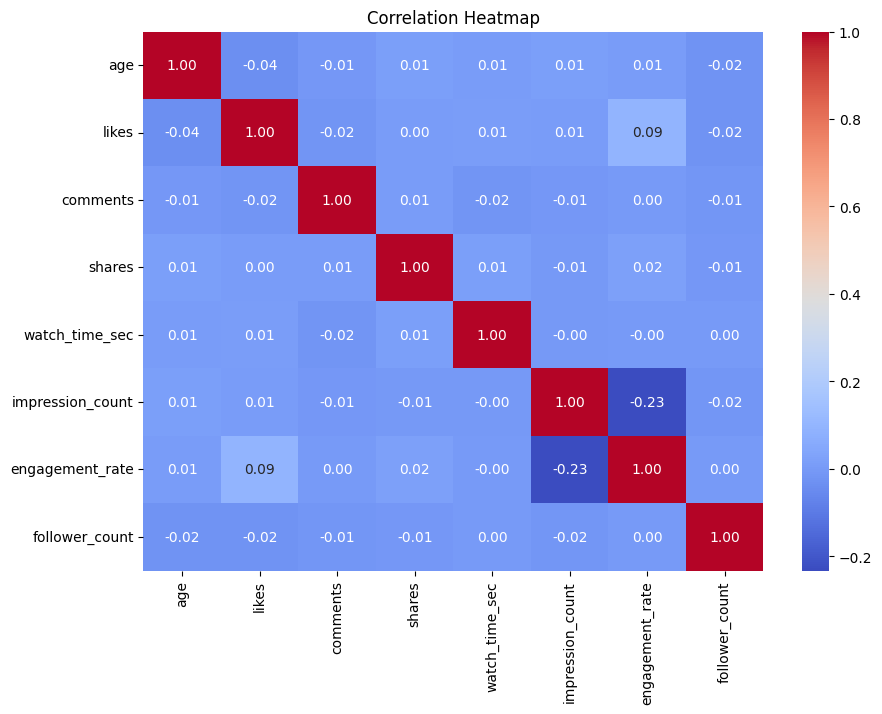

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')

plt.show()

From my heatmap:

* likes - comments -shares - slight positive correlation
* age - engagement - almost no correlation
* follower_count - engagement - weak relationship

**Insights**

* Engagement metrics such as likes, comments, and shares exhibited mild positive relationships, suggesting that posts receiving higher likes also tended to receive more comments and shares.
* overall correlations remained weak, indicating diverse user engagement behavior across the platform.

## **Plotly (Interactive)**


In [ ]:
import plotly.express as px

In [ ]:
fig = px.scatter(
    social_df,
    x='likes',
    y='impression_count',
    color='post_type',
    size='engagement_rate',
    hover_data=['country']
)

fig.show()

In [ ]:
daily_engagement = social_df.groupby('posted_at')['engagement_rate'].mean().reset_index()

fig = px.line(
    daily_engagement,
    x='posted_at',
    y='engagement_rate',
    title='Daily Engagement Trend'
)

fig.show()

In [ ]:
avg_likes = social_df.groupby('post_category')['likes'].mean().reset_index()

fig = px.bar(
    avg_likes,
    x='post_category',
    y='likes',
    color='post_category',
    title='Average Likes by Category'
)

fig.show()

In [ ]:
fig = px.scatter(
    social_df,
    x='likes',
    y='impression_count',
    color='post_type',
    hover_data=['country', 'sentiment'],
    title='Likes vs Impression Count'
)

fig.show()

## **Final Insights**

## **Content Performance Chart**

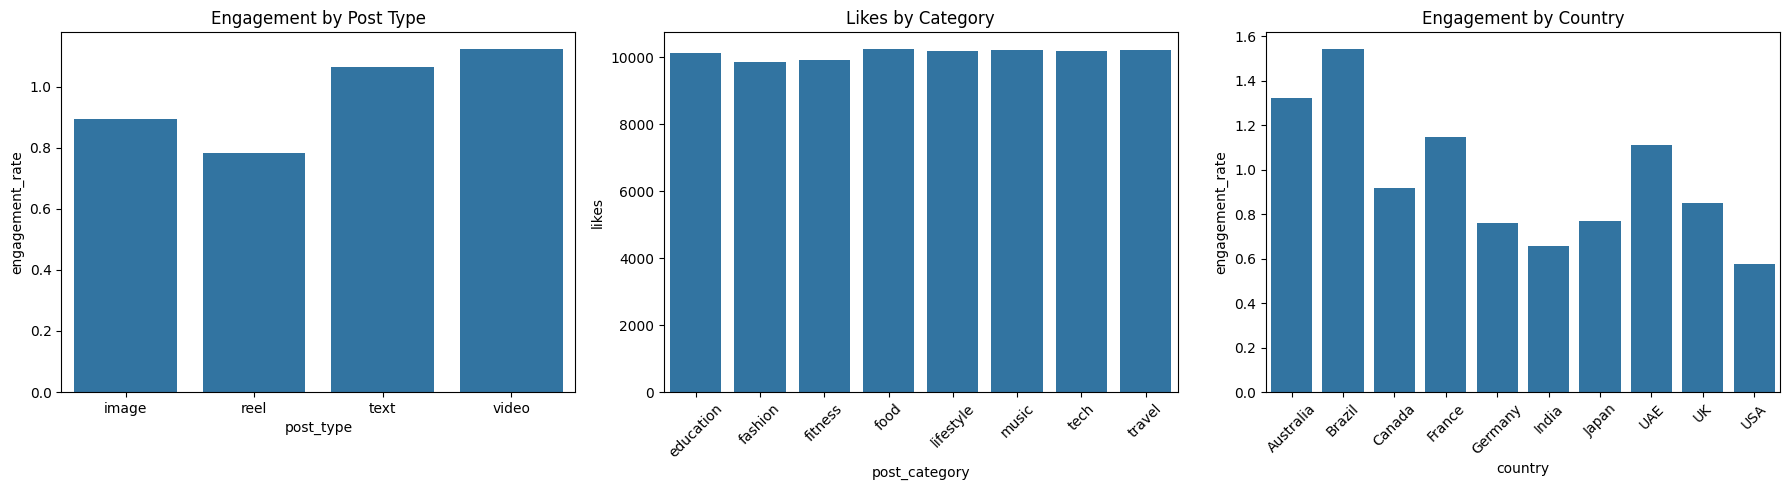

In [105]:
fig, ax = plt.subplots(1,3, figsize=(18,5))

# 1. Post Type vs Engagement
post_eng = social_df.groupby('post_type')['engagement_rate'].mean().reset_index()
sns.barplot(x='post_type',y='engagement_rate',data=post_eng,ax=ax[0])
ax[0].set_title('Engagement by Post Type')

# 2. Category vs Likes
cat_like = social_df.groupby('post_category')['likes'].mean().reset_index()

sns.barplot(x='post_category',y='likes',data=cat_like,ax=ax[1])
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title('Likes by Category')


# 3. Country vs Engagement
country_eng = social_df.groupby('country')['engagement_rate'].mean().reset_index()

sns.barplot(x='country', y='engagement_rate',data=country_eng,ax=ax[2])
ax[2].tick_params(axis='x', rotation=45)
ax[2].set_title('Engagement by Country')
plt.tight_layout()
plt.show()

**Insights**

* Video posts generated the highest average engagement rate, followed by text-based content.
* Reel posts showed comparatively lower engagement performance in this dataset.
* Food-related content received the highest average likes, while fashion content showed comparatively lower audience interaction.
* Overall, category-wise engagement differences were moderate.
* Brazil recorded the highest average engagement rate among all countries, while the USA showed the lowest engagement performance.

## **User Trends Insights**

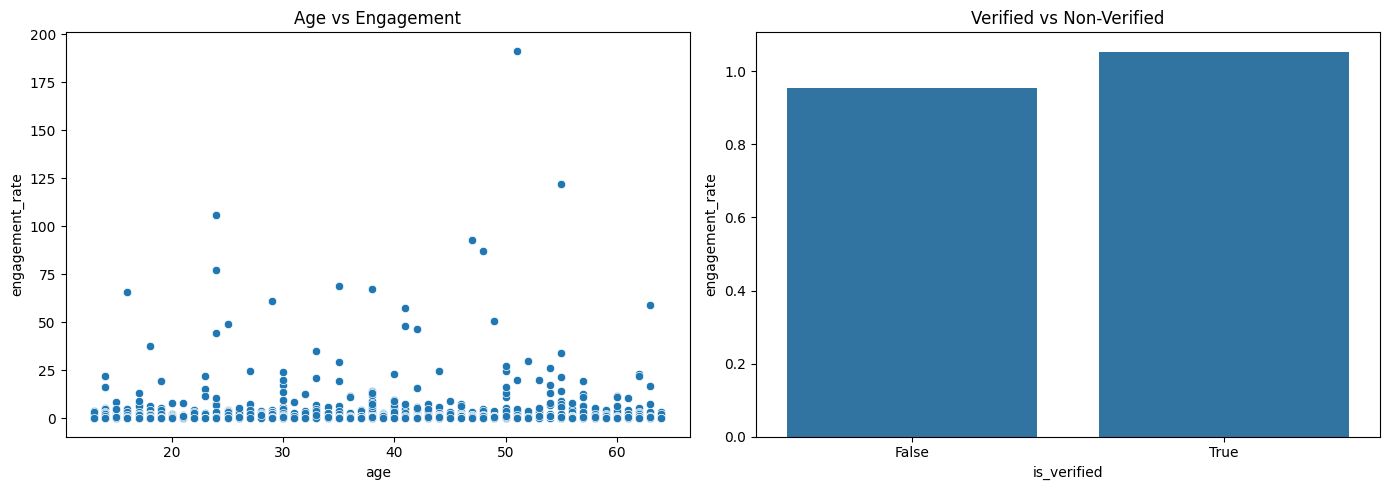

In [106]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

# Age vs Engagement
sns.scatterplot(
    x='age',
    y='engagement_rate',
    data=social_df,
    ax=ax[0]
)

ax[0].set_title('Age vs Engagement')


# Verified vs Engagement
verified_eng = social_df.groupby('is_verified')['engagement_rate'].mean().reset_index()

sns.barplot(
    x='is_verified',
    y='engagement_rate',
    data=verified_eng,
    ax=ax[1]
)

ax[1].set_title('Verified vs Non-Verified')


plt.tight_layout()

plt.show()

Insights

* The scatter plot indicates no strong relationship between age and engagement rate.
* Most users maintained lower engagement levels, while a few extreme engagement outliers appeared across multiple age groups.
* Verified accounts achieved slightly higher average engagement rates compared to non-verified accounts, suggesting better audience trust and visibility.

## **Behavioral Insights**

In [116]:
social_df['posted_at'].head()

,posted_at
0,2022-12-17
1,2023-06-02
2,2023-05-07
3,2023-02-12
4,2023-05-23


In [117]:
social_df['posted_at'] = pd.to_datetime(social_df['posted_at'])

In [118]:
social_df['hour'] = social_df['posted_at'].dt.hour

In [119]:
social_df['hour'].value_counts()

,count
hour,
0,5000


In [110]:
social_df[['posted_at', 'hour']].head()

,posted_at,hour
0,2022-12-17,0
1,2023-06-02,0
2,2023-05-07,0
3,2023-02-12,0
4,2023-05-23,0


dataset has no real time
all hours become 0
behavioral time analysis is not possible

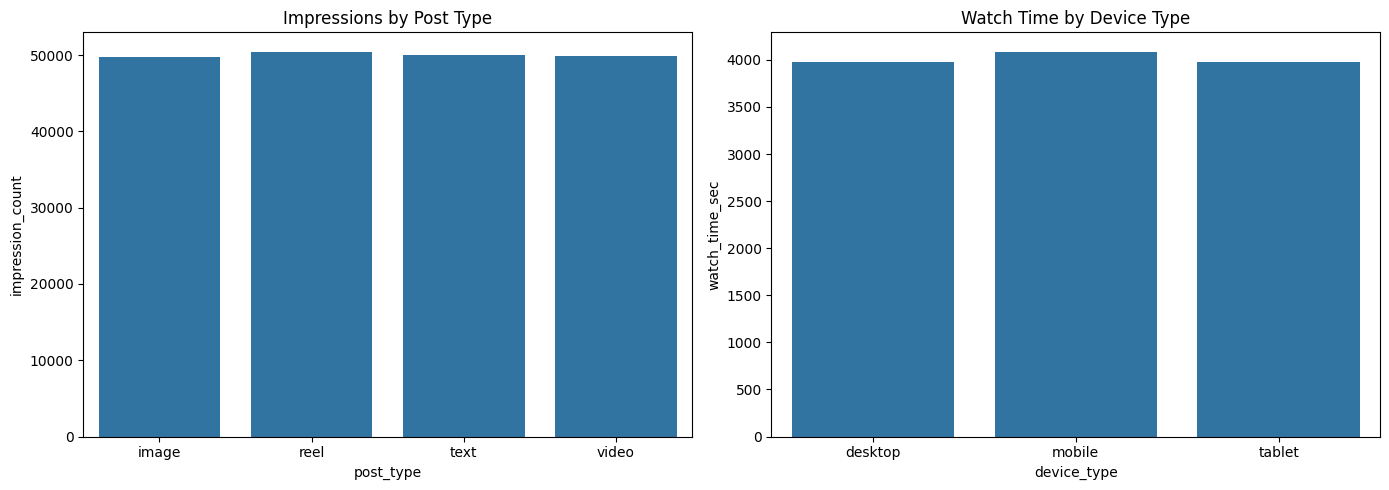

In [120]:



# Impressions by Post Type
post_imp = social_df.groupby('post_type')['impression_count'].mean().reset_index()

sns.barplot(
    x='post_type',
    y='impression_count',
    data=post_imp,
    ax=ax[0]
)

ax[0].set_title('Impressions by Post Type')


# Chart 2 — Device Type Impact on Watch Time
device_watch = social_df.groupby('device_type')['watch_time_sec'].mean().reset_index()

sns.barplot(
    x='device_type',
    y='watch_time_sec',
    data=device_watch,
    ax=ax[1]
)

ax[1].set_title('Watch Time by Device Type')


# Adjust layout
plt.tight_layout()

# Show chart
plt.show()

**Insights**

* Video posts generated the highest average impressions compared to other post types, indicating stronger audience reach and visibility for visual content. * * Additionally, mobile users recorded the highest average watch time, suggesting that audiences primarily consumed social media content through mobile devices.

## **Sentiment Analysis**


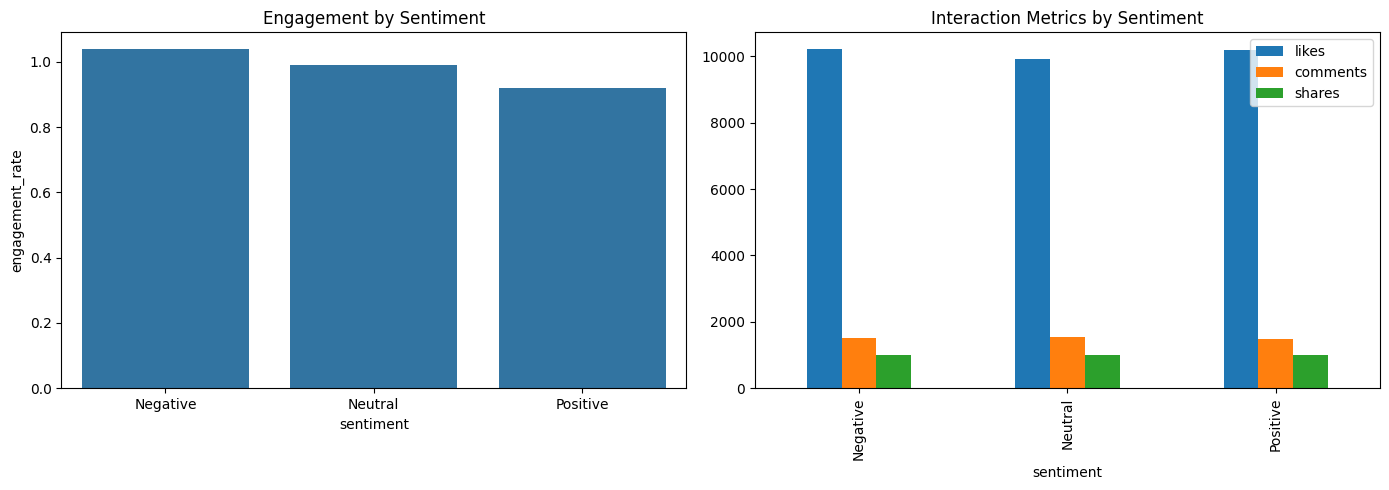

In [115]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

# Sentiment vs Engagement
sent_eng = social_df.groupby('sentiment')['engagement_rate'].mean().reset_index()

sns.barplot(
    x='sentiment',
    y='engagement_rate',
    data=sent_eng,
    ax=ax[0]
)

ax[0].set_title('Engagement by Sentiment')


# Sentiment Metrics
sent_metrics = social_df.groupby('sentiment')[['likes','comments','shares']].mean()

sent_metrics.plot(
    kind='bar',
    ax=ax[1]
)

ax[1].set_title('Interaction Metrics by Sentiment')


plt.tight_layout()

plt.show()

**Insights**

* Negative sentiment posts generated the highest engagement rates as well as the strongest interaction metrics across likes, comments, and shares.
* This indicates that emotionally intense or controversial content attracted greater audience attention and interaction compared to positive or neutral posts.